In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Danso Emmanuel Effah\OneDrive\Desktop\DATA ANALYSIS\Projects\India Project\iris.csv")

###Cleaning columns
df.columns = df.columns.str.strip()

print(df.head())
print(df.columns)

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')


In [2]:
# Dropping species as i do not need it for clusttering
X = df.drop("species", axis=1)

In [3]:
## standardizing the data set
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

C:\Users\Danso Emmanuel Effah\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Danso Emmanuel Effah\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Danso Emmanuel Effah\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Danso Emmanuel Effah\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: 

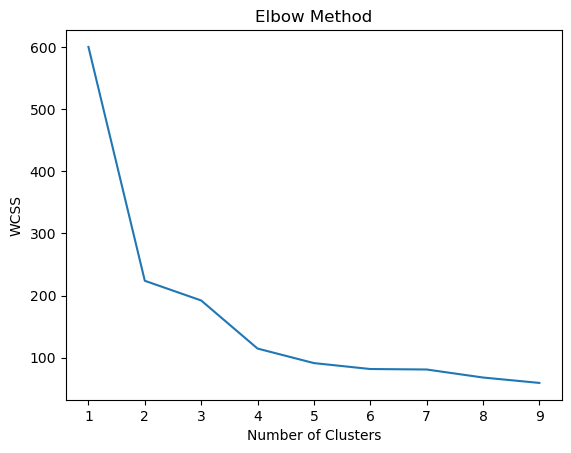

In [4]:
## using the elbow method
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 10), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [9]:
## applying k-means
kmeans = KMeans(n_clusters=3, random_state=42)

df["Cluster"] = kmeans.fit_predict(X_scaled)

C:\Users\Danso Emmanuel Effah\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


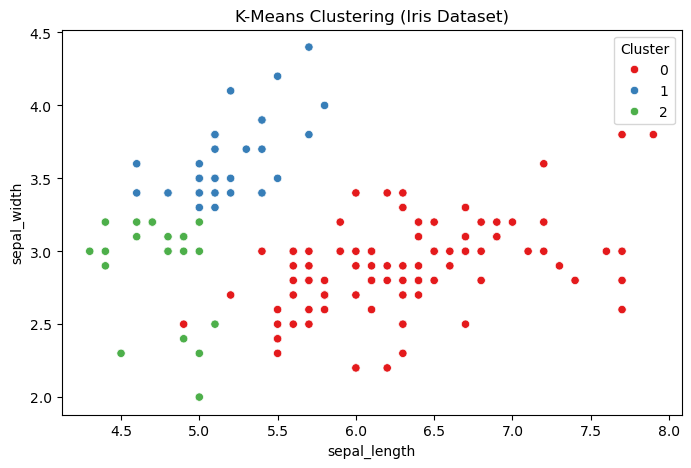

In [7]:
### visualizing clusters 
import seaborn as sns

plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df.iloc[:, 0],
    y=df.iloc[:, 1],
    hue=df["Cluster"],
    palette="Set1"
)

plt.title("K-Means Clustering (Iris Dataset)")
plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])
plt.show()

In [8]:
###evaluating clusters values
print(pd.crosstab(df["species"], df["Cluster"]))

Cluster      0   1   2
species               
setosa       0  32  18
versicolor  46   0   4
virginica   50   0   0
